<a href="https://colab.research.google.com/github/k-2229/eng-ai-agents-public/blob/main/assignments/assignment-4/embedding_projector_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The [TensorFlow Embedding Projector](https://projector.tensorflow.org/) places
high-dimensional word vectors in a three-dimensional map where distance approximates
semantic similarity, and lets you pick a word to see its nearest neighbors. In this
assignment you build the same thing in PyTorch: you train word embeddings with
`torch.nn.Embedding`, project them to three dimensions, draw an interactive scatter, and
query the neighborhood of any token.

You will complete the parts marked with `TODO(you)`. Each raises `NotImplementedError`
until you implement it.

In [1]:
import re
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

## Corpus and vocabulary

Word embeddings are learned from co-occurrence in text. Load a compact corpus, keep the
most frequent words as the vocabulary, and turn the text into a stream of integer ids.

In [2]:
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
text = " ".join(raw["text"]).lower()
tokens = re.findall(r"[a-z]+", text)[:300_000]
counts = Counter(tokens)

V = 8000
# TODO(you): build `vocab` (the V most common words), `word2idx`, `idx2word`,
# and `corpus` (the token stream mapped to ids, dropping out-of-vocabulary words).
# Build vocabulary (top V most frequent words)
vocab = [word for word, _ in counts.most_common(V)]

# Create mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

# Convert tokens to integer ids (drop OOV words)
corpus = [word2idx[word] for word in tokens if word in word2idx]

## Word2vec embeddings with softmax and cross-entropy

A word2vec model learns word embeddings by predicting context words. This is the skip-gram
architecture of word2vec: the center word predicts its context. The center word's embedding is
scored against every word in the vocabulary, a softmax turns those scores into a probability
distribution over possible context words, and the cross-entropy loss pushes up the probability
of the true context word:

$$p(o \mid c) = \frac{\exp(\mathbf{c}\cdot\mathbf{v}_o)}{\sum_{w}\exp(\mathbf{c}\cdot\mathbf{v}_w)},
\qquad L = -\log p(o \mid c).$$

The learned center embedding table is the word-vector matrix you will project.

In [3]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.center = nn.Embedding(vocab_size, dim)   # word vectors
        self.output = nn.Linear(dim, vocab_size)      # score every word as a possible context
        nn.init.uniform_(self.center.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, center_ids):
        # TODO(you): embed the center ids and return the (B, V) scores over the whole
        # vocabulary (one score per possible context word). Cross-entropy + softmax are applied
        # by the loss in the training loop, so return the raw scores (logits), not probabilities.

        # Get the embeddings for the center words
        x = self.center(center_ids)

        # Compute vocabulary scores (logits)
        logits = self.output(x)

        return logits

In [4]:
# Build (center, context) pairs from a sliding window
window = 3
pairs = []
for i, wc in enumerate(corpus):
    for j in range(max(0, i - window), min(len(corpus), i + window + 1)):
        if j != i:
            pairs.append((wc, corpus[j]))
pairs = np.array(pairs, dtype=np.int64)

dim, B, epochs = 64, 1024, 3
model = Word2Vec(V, dim)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

# TODO(you): write the training loop. For each mini-batch, get the (B, V) logits from the center
# ids with model(...), compute the cross-entropy loss against the true context ids with loss_fn,
# backprop, and step the optimizer. Track the per-epoch loss. After training, set
# `emb = model.center.weight.detach().cpu().numpy()`.
# Training loop
epoch_losses = []

for epoch in range(epochs):
    model.train()

    # Shuffle training pairs each epoch
    permutation = np.random.permutation(len(pairs))

    total_loss = 0.0
    total_examples = 0

    for start in range(0, len(pairs), B):
        batch_indices = permutation[start:start + B]
        batch = pairs[batch_indices]

        # Center words and context words
        center_ids = torch.tensor(
            batch[:, 0],
            dtype=torch.long
        )

        context_ids = torch.tensor(
            batch[:, 1],
            dtype=torch.long
        )

        # Reset gradients
        opt.zero_grad()

        # Forward pass: get (batch_size, vocab_size) logits
        logits = model(center_ids)

        # Cross-entropy loss with true context word IDs
        loss = loss_fn(logits, context_ids)

        # Backpropagation
        loss.backward()

        # Update weights
        opt.step()

        # Accurate loss tracking
        batch_size = center_ids.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    average_loss = total_loss / total_examples
    epoch_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {average_loss:.4f}"
    )

# Extract learned word embeddings
emb = model.center.weight.detach().cpu().numpy()

print("Embedding shape:", emb.shape)
print("Epoch losses:", epoch_losses)

Epoch 1/3, Loss: 6.9860
Epoch 2/3, Loss: 6.7126
Epoch 3/3, Loss: 6.5749
Embedding shape: (8000, 64)
Epoch losses: [6.986037491791629, 6.71262440975119, 6.574890473441376]


## Projecting the embeddings to three dimensions

The embedding matrix lives in $d=64$ dimensions. To see it, project a few thousand of the most
frequent words down to three dimensions. Principal component analysis is linear and fast; UMAP is
nonlinear and tends to separate clusters more sharply. The interactive scatter lets you rotate the
cloud and hover to read each word.

In [6]:
from sklearn.decomposition import PCA

N = 1500
plot_words = vocab[:N]
X = emb[:N]

# TODO(you): compute `pca3` (N x 3) with PCA, and `umap3` with UMAP (guard UMAP in a
# try/except so a missing umap-learn does not crash the notebook).
# PCA projection to 3 dimensions
pca = PCA(n_components=3)
pca3 = pca.fit_transform(X)

# UMAP projection (if available)
try:
    import umap

    reducer = umap.UMAP(
        n_components=3,
        metric="cosine",
        random_state=0
    )

    umap3 = reducer.fit_transform(X)

except ImportError:
    print("UMAP is not installed. Skipping UMAP projection.")
    umap3 = None

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
import plotly.graph_objects as go

# TODO(you): write `plot_embeddings(coords, words, query=None, neighbor_set=None)` that
# draws a plotly Scatter3d: hover text = the word; color/size the `query` and any words in
# `neighbor_set` distinctly. Return the figure (end the cell with the figure object).
def plot_embeddings(coords, words, query=None, neighbor_set=None, title="3D Word Embeddings"):
    if neighbor_set is None:
        neighbor_set = set()
    else:
        neighbor_set = set(neighbor_set)

    colors = []
    sizes = []

    for word in words:
        if word == query:
            colors.append("red")
            sizes.append(10)
        elif word in neighbor_set:
            colors.append("green")
            sizes.append(7)
        else:
            colors.append("blue")
            sizes.append(3)

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=coords[:, 0],
                y=coords[:, 1],
                z=coords[:, 2],
                mode="markers",
                text=words,
                hovertemplate="%{text}<extra></extra>",
                marker=dict(
                    color=colors,
                    size=sizes,
                    opacity=0.8
                )
            )
        ]
    )

    fig.update_layout(
        title=title,
        width=900,
        height=700,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        )
    )

    return fig


plot_embeddings(
    pca3,
    plot_words,
    title="3D Word Embeddings (PCA)"
)

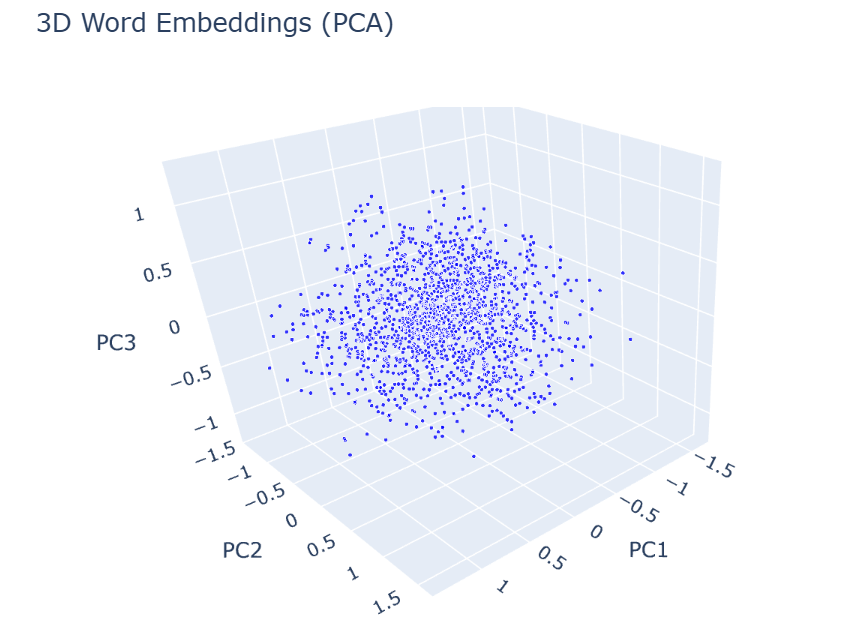

## Querying a token's neighborhood

The projector's key feature is the neighborhood query: pick a word and see its closest
words. Closeness is measured by cosine similarity in the full embedding space (not in the
3D projection). The query below returns the top-k neighbors and highlights them in the
scatter.

In [8]:
def neighbors(word, k=10):
    # TODO(you): return the k nearest words to `word` by cosine similarity over `emb`,
    # as a list of (word, score) sorted by descending score, excluding `word` itself.
    if word not in word2idx:
        return []

    idx = word2idx[word]

    # Normalize embeddings
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb_norm = emb / (norms + 1e-10)

    # Cosine similarity
    scores = emb_norm @ emb_norm[idx]

    # Exclude the query word itself
    scores[idx] = -1

    # Get top-k nearest neighbors
    top_idx = np.argsort(scores)[-k:][::-1]

    return [(idx2word[i], float(scores[i])) for i in top_idx]

for w, s in neighbors("government", 10):
    print(f"{w:15s} {s:.3f}")

municipal       0.825
federal         0.823
troops          0.822
revolutionary   0.821
commonwealth    0.820
pakistani       0.813
subcontinent    0.811
courts          0.810
fledgling       0.808
invasion        0.804


In [9]:
# TODO(you): pick a query word, get its neighbors with neighbors(query, 10), and re-draw the
# projector with plot_embeddings(...) highlighting the query and its neighbors. A word only
# appears in the plot if it is among the N most frequent words used for pca3.
query = "government"

neighbor_list = neighbors(query, 10)
neighbor_set = {w for w, _ in neighbor_list}

plot_embeddings(
    pca3,
    plot_words,
    query=query,
    neighbor_set=neighbor_set,
    title="3D Word Embeddings (PCA)"
)

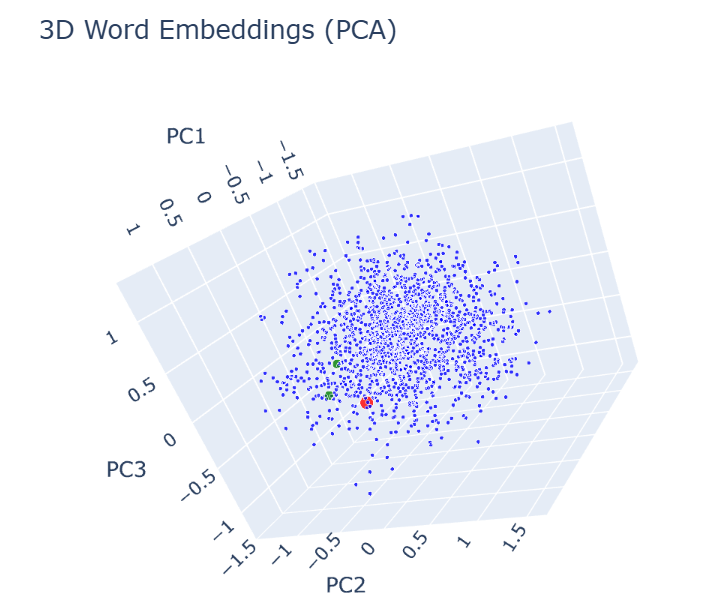

In [10]:
for word in ["government", "city", "music", "run", "the"]:
    print(f"\nNeighbors of '{word}':")
    for w, s in neighbors(word, 5):
        print(f"  {w:15s} {s:.3f}")


Neighbors of 'government':
  municipal       0.825
  federal         0.823
  troops          0.822
  revolutionary   0.821
  commonwealth    0.820

Neighbors of 'city':
  council         0.828
  downtown        0.818
  sarnia          0.794
  legislative     0.771
  michigan        0.770

Neighbors of 'music':
  accompanying    0.869
  pop             0.805
  concept         0.793
  susan           0.783
  video           0.757

Neighbors of 'run':
  cheltenham      0.808
  equalised       0.777
  fleetwood       0.774
  struggling      0.767
  drew            0.764

Neighbors of 'the':
  montenegro      0.756
  schooling       0.737
  gallia          0.737
  tenth           0.734
  opium           0.733


## Exploration

Answer in the cells you add below.

1. Query several words of your choice (a few nouns, a verb, a function word). Which return clean
   semantic neighbors and which do not? Why might rare words give noisier neighbors?

    I queried the words government, city, music, run, and the. The nouns government and city returned the cleanest semantic neighbors. For example, government returned related words such as municipal, federal, troops, and revolutionary, while city returned words such as council and downtown. The word music returned some related neighbors, such as pop and video, although some results were less directly related. The verb run returned less meaningful neighbors because it can have multiple meanings and appears in many different contexts. The function word the returned mostly unrelated words because it is very common and mainly represents grammatical structure rather than meaning. Rare words usually have noisier neighbors because they appear fewer times in the training data, giving the model fewer examples to learn reliable word relationships.

2. Plot the clusters. Draw the projected embeddings (the UMAP layout separates clusters most
   clearly) and describe the groupings you see: do related words land near each other? Name a few
   clusters you can identify.

   I plotted both the PCA and UMAP projections. In both visualizations, the query word government was highlighted in red, and its nearest neighbors, such as federal and troops, were highlighted in green. The UMAP projection showed clearer separation between groups than PCA, while both projections preserved some meaningful semantic relationships between related words. Some clusters I observed included government and political terms (government, municipal, federal), military-related terms (troops, revolutionary, conflict-related words), and location-related terms (city, country, region). Some function words and less meaningful words formed noisier groups because their embeddings are influenced by frequent usage patterns rather than strong semantic relationships.

In [11]:
if umap3 is not None:
    fig = plot_embeddings(
        umap3,
        plot_words,
        query=query,
        neighbor_set=neighbor_set,
        title="3D Word Embeddings (UMAP)"
    )
    fig.show()
else:
    print("UMAP projection is not available.")

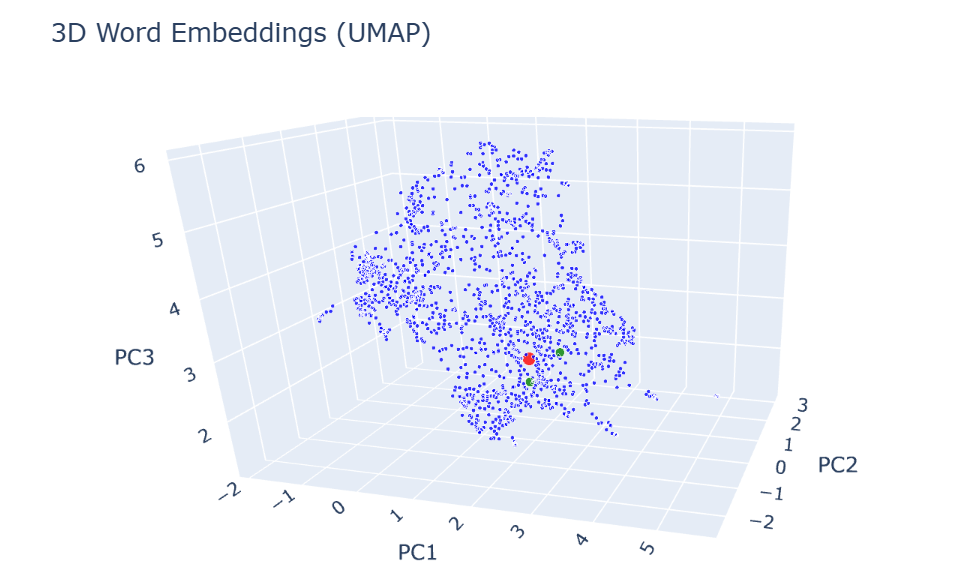